In [1]:
import pandas as pd


In [2]:
degs_8W_M = pd.read_csv('/Users/derekebowman/Coding Projects/taPVAT_snRNAseq_analysis/code/scVelo_and_CellOracle/CellOracle/DEG_Data/taPVAT_Adipocytes_Brown_HF_8W_M_vs_Control_8W_M_diet_comparison_deseq_all_genes.txt', sep='\t')

In [3]:
predictions_8W_M = pd.read_csv('/Users/derekebowman/Coding Projects/taPVAT_snRNAseq_analysis/code/scVelo_and_CellOracle/CellOracle/scVIDR_Gene_Score_Predictions/August18_10_19_gene_scores_Adipocytes_Brown_8W_M.csv')

In [7]:
predictions_8W_M = predictions_8W_M[~predictions_8W_M['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
predictions_8W_M = predictions_8W_M[~predictions_8W_M['Gene'].str.startswith('AABR')]
predictions_8W_M = predictions_8W_M[~predictions_8W_M['Gene'].str.startswith('ENSRN')]

In [8]:
degs_8W_M = degs_8W_M[degs_8W_M['padj'] <= 0.05]
degs_8W_M = degs_8W_M[~degs_8W_M['gene_id'].str.startswith('Mt-')] # Removed mitochondrial genes
degs_8W_M = degs_8W_M[~degs_8W_M['gene_id'].str.startswith('AABR')]
degs_8W_M = degs_8W_M[~degs_8W_M['gene_id'].str.startswith('ENSRN')]

degs_8W_M

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,celltype,group,group1,group2
91,AC096301.1,102.079589,3.253429,0.508158,6.402399,1.529547e-10,4.156630e-08,AC096301.1,Adipocytes_Brown,diet,Control,HF
98,AC125757.1,247.826089,2.024450,0.606219,3.339471,8.393809e-04,2.606782e-02,AC125757.1,Adipocytes_Brown,diet,Control,HF
117,Abca1,216.017663,-2.339604,0.505163,-4.631381,3.632352e-06,2.941724e-04,Abca1,Adipocytes_Brown,diet,Control,HF
123,Abca8,31.141335,2.499668,0.611301,4.089096,4.330572e-05,2.322744e-03,Abca8,Adipocytes_Brown,diet,Control,HF
124,Abca8a,165.083116,2.530050,0.341820,7.401713,1.344384e-13,6.576191e-11,Abca8a,Adipocytes_Brown,diet,Control,HF
...,...,...,...,...,...,...,...,...,...,...,...,...
11896,Zfp142,729.963488,0.818322,0.246352,3.321759,8.945207e-04,2.753318e-02,Zfp142,Adipocytes_Brown,diet,Control,HF
11907,Zfp189,145.697674,-1.854785,0.412168,-4.500071,6.793085e-06,4.897209e-04,Zfp189,Adipocytes_Brown,diet,Control,HF
11964,Zfp385c,84.743598,1.783930,0.475802,3.749309,1.773222e-04,7.301257e-03,Zfp385c,Adipocytes_Brown,diet,Control,HF
12069,Zfp711,10.352797,4.511551,1.183551,3.811876,1.379163e-04,5.980775e-03,Zfp711,Adipocytes_Brown,diet,Control,HF


In [10]:
degs_up_in_HF = degs_8W_M[degs_8W_M['log2FoldChange'] >= 1.0]
degs_down_in_HF = degs_8W_M[degs_8W_M['log2FoldChange'] <= -1.0]

In [11]:
upregulated_predictions_8W_M = predictions_8W_M[predictions_8W_M['Gene'].isin(list(degs_up_in_HF['gene_id']))]
downregulated_predictions_8W_M = predictions_8W_M[predictions_8W_M['Gene'].isin(list(degs_down_in_HF['gene_id']))]

In [12]:
gene_to_logfc = degs_8W_M.set_index('gene_id')['log2FoldChange']
downregulated_predictions_8W_M['GroundTruthLog2FC'] = downregulated_predictions_8W_M['Gene'].map(gene_to_logfc)
upregulated_predictions_8W_M['GroundTruthLog2FC'] = upregulated_predictions_8W_M['Gene'].map(gene_to_logfc)


/tmp/ipykernel_3716004/3460465846.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated_predictions_8W_M['GroundTruthLog2FC'] = downregulated_predictions_8W_M['Gene'].map(gene_to_logfc)
/tmp/ipykernel_3716004/3460465846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upregulated_predictions_8W_M['GroundTruthLog2FC'] = upregulated_predictions_8W_M['Gene'].map(gene_to_logfc)


In [13]:
upregulated_predictions_8W_M.sort_values(by='Score', inplace=True, ascending=False)
downregulated_predictions_8W_M.sort_values(by='Score', inplace=True, ascending=True)

/tmp/ipykernel_3716004/3027829417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upregulated_predictions_8W_M.sort_values(by='Score', inplace=True, ascending=False)
/tmp/ipykernel_3716004/3027829417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated_predictions_8W_M.sort_values(by='Score', inplace=True, ascending=True)


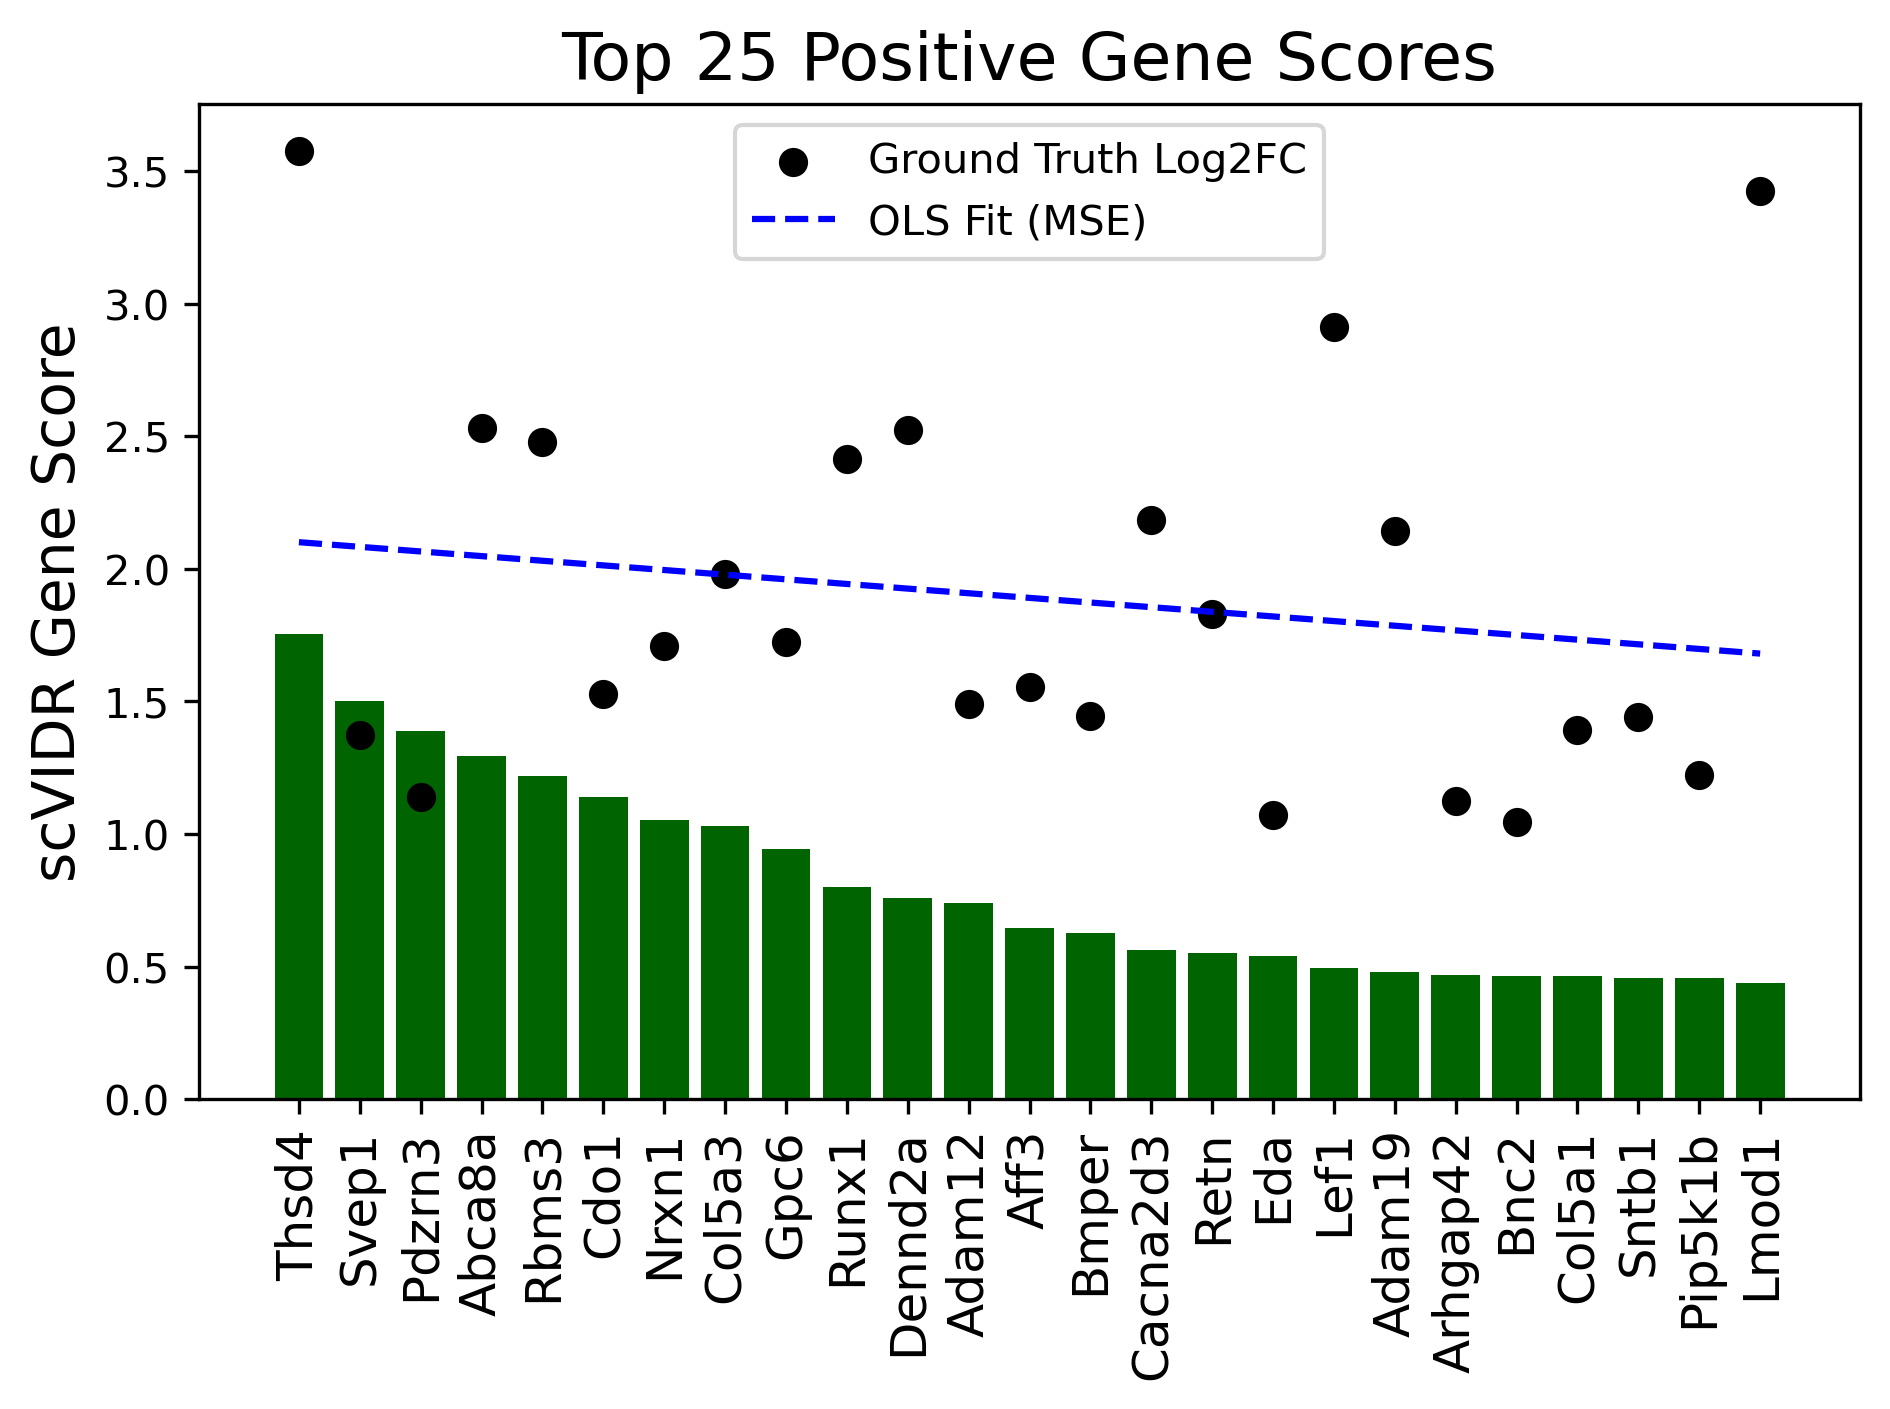

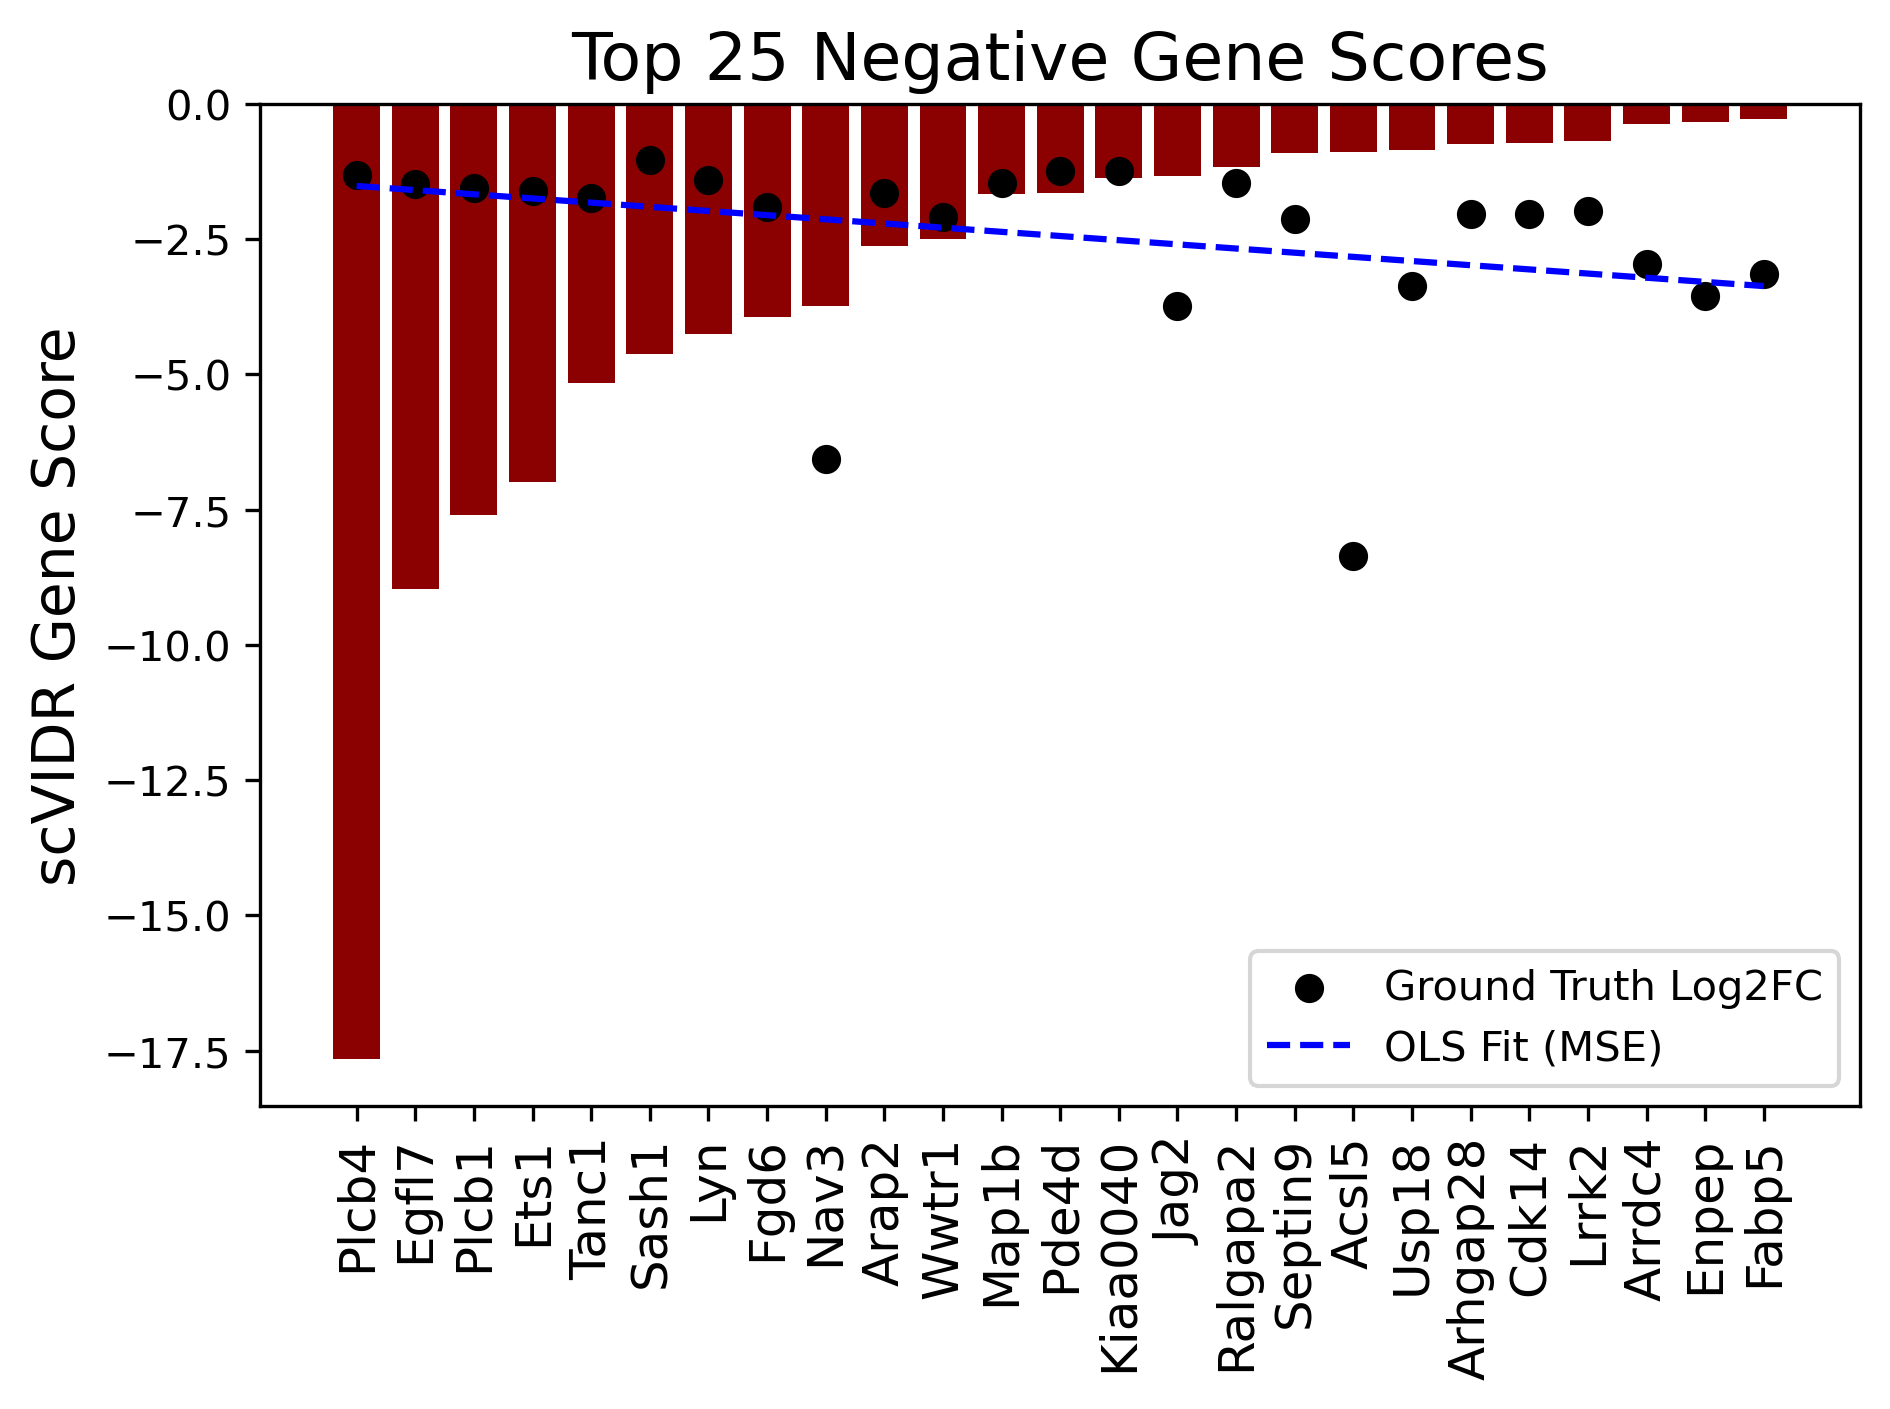

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression


# Top 25 most positive gene scores
top_pos = upregulated_predictions_8W_M.head(25)

plt.figure(dpi=300)
plt.bar(top_pos['Gene'], top_pos['Score'], color='darkgreen')
plt.scatter(top_pos['Gene'], top_pos['GroundTruthLog2FC'], color='black', label='Ground Truth Log2FC')



X = np.arange(len(top_pos['Gene'])).reshape(-1, 1)
y = top_pos['GroundTruthLog2FC'].values


ols = LinearRegression()
ols.fit(X, y)

y_pred = ols.predict(X)






plt.plot(top_pos['Gene'], y_pred, color='blue', linestyle='--', label='OLS Fit (MSE)')
plt.legend()

plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 25 Positive Gene Scores", fontsize=16)
plt.tight_layout()
#plt.savefig("../figures/Top25PositiveGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()




# Top 25 most negative gene scores
top_neg = downregulated_predictions_8W_M.head(25)
plt.figure(dpi=300)
plt.bar(top_neg['Gene'], top_neg['Score'], color='darkred')
plt.scatter(top_neg['Gene'], top_neg['GroundTruthLog2FC'], color='black', label='Ground Truth Log2FC')


X = np.arange(len(top_neg['Gene'])).reshape(-1, 1)
y = top_neg['GroundTruthLog2FC'].values


ols = LinearRegression()
ols.fit(X, y)

y_pred = ols.predict(X)

plt.plot(top_neg['Gene'], y_pred, color='blue', linestyle='--', label='OLS Fit (MSE)')
    
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 25 Negative Gene Scores", fontsize=16)
plt.legend()
plt.tight_layout()
#plt.savefig("../figures/Top25NegativeGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()
